# Visualize SCALP-lite Embedding

Set `SCALP_INPUT_H5AD` to your input file. Optionally set `SCALP_OUTPUT_H5AD` for the annotated output.

In [1]:
import os
from pathlib import Path

import pandas as pd

from scalp_lite import ScalpEstimator, save_h5ad, plot_embedding_pair


def resolve_path(env_name, default):
    path = Path(os.environ.get(env_name, default))
    if path.exists() or path.is_absolute():
        return path
    notebook_relative = Path("..") / path
    return notebook_relative if notebook_relative.exists() else path


input_path = resolve_path("SCALP_INPUT_H5AD", "data/cellrank-pancreas.h5ad")
output_path = Path(os.environ["SCALP_OUTPUT_H5AD"]) if "SCALP_OUTPUT_H5AD" in os.environ else input_path.with_name(f"{input_path.stem}-scalp.h5ad")
batch_key = os.environ.get("SCALP_BATCH_KEY", "batch")
label_key = os.environ.get("SCALP_LABEL_KEY", "label")

estimator = ScalpEstimator(batch_key=batch_key, label_key=label_key)


In [2]:
adata = estimator.input(input_path)

if batch_key not in adata.obs:
    # The bundled development dataset has no true batch, so split cells deterministically for smoke testing.
    adata.obs[batch_key] = pd.Categorical([f"split_{i % 3}" for i in range(adata.n_obs)])

if label_key not in adata.obs:
    for candidate in ("clusters_coarse", "cell_type", "clusters_fine", "clusters",  "leiden", "louvain"):
        if candidate in adata.obs:
            adata.obs[label_key] = adata.obs[candidate].astype("category")
            break

adata = estimator.preprocess(adata, n_top_genes=2000, max_cells=None)
adata


AnnData object with n_obs × n_vars = 2531 × 2000
    obs: 'day', 'proliferation', 'G2M_score', 'S_score', 'phase', 'clusters_coarse', 'clusters', 'clusters_fine', 'louvain_Alpha', 'louvain_Beta', 'palantir_pseudotime', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'terminal_states', 'terminal_states_probs', 'initial_states', 'initial_states_probs', 'velocity_pseudotime', 'latent_time', 'dpt_pseudotime', 'batch', 'label'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes', 'to Epsilon corr', 'to Alpha corr', 'to Beta corr', 'to Epsilon qval', 'to Alpha qval', 'to Beta qval'
    uns: 'T_bwd_params', 'clusters_colors', 'clust

In [ ]:
graph = estimator.data_to_graph(
    adata,
    n_neighbors=15,
    intra_fraction=0.5,
    n_inter_edges=1,
    assignment_quantile=0.95,
    symmetrize=True,
)
adata.obsm["X_scalp"] = estimator.graph_to_vector(graph)


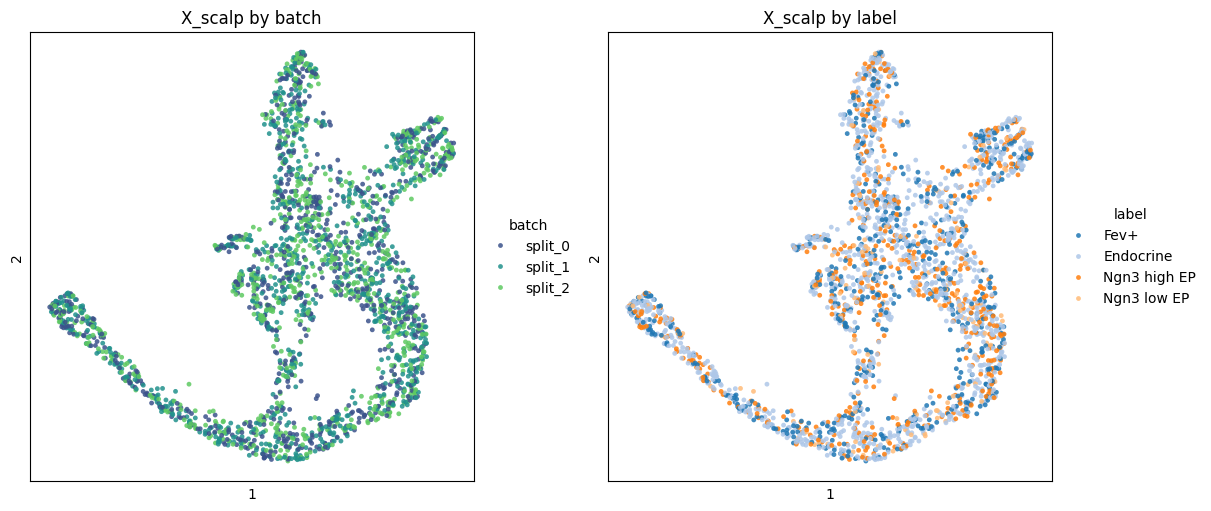

In [4]:
plot_embedding_pair(adata, embedding_key="X_scalp", batch_key=batch_key, label_key=label_key);


In [5]:
save_h5ad(adata, output_path)
output_path

PosixPath('../data/cellrank-pancreas-scalp.h5ad')